
# Machine Learning I Final Project

Created by: Michael Doughty


# Dataset Description: Medical (Classification)

## Target
- **target**: Predict whether a patient will be readmitted (1) or not (0).

## Features
- **age**: Patient age in years (min=18, max=90)
- **sex**: Biological sex
- **bmi**: Body Mass Index (min=15, max=55)
- **number_of_prior_admissions**: Number of prior hospital admissions (min=0, max=20)
- **chronic_conditions_count**: Number of chronic conditions (min=0, max=10)
- **admission_type**: Type of hospital admission
- **severity_score**: Overall severity of patient condition (min=0, max=100)
- **lab_result_severity**: Severity indicated by lab results (min=0, max=100)
- **vitals_instability_score**: Instability of vital signs (min=0, max=100)
- **treatment_complexity**: Complexity of treatment required (min=0, max=100)
- **hospital_load_index**: Current hospital capacity utilization (min=0, max=1)
- **physician_workload**: Relative workload of physicians (min=0, max=1)

## Your objectives:
- Train at least 3 classification models
- Evaluate using accuracy, precision, recall, and F1-score
- Compare model performance
- Identify important features


## Project Instructions

1. Load the dataset
2. Perform exploratory data analysis
3. Clean and preprocess the data
4. Train machine learning models
5. Evaluate models

In [1]:
# Basic imports
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Imputer
from sklearn.impute import SimpleImputer
from sklearn.impute import KNNImputer
# Pipelines
from sklearn.pipeline import Pipeline
# Train/test split
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
# Scalers
from sklearn.preprocessing import StandardScaler
# ML models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# Metrics
from sklearn.metrics import accuracy_score, classification_report, precision_recall_curve, roc_curve, auc, precision_score, recall_score, roc_auc_score, confusion_matrix, f1_score


## Load Dataset

In [2]:
# Load the dataset.
df_medical = pd.read_csv("../datasets/MichaelDoughty_088271_dataset.csv")

### Basic Dataset Information

In [3]:
#Retrieve basic information about the dataset.
df_medical.info()
df_medical.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1020 entries, 0 to 1019
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   age                         978 non-null    float64
 1   sex                         973 non-null    object 
 2   bmi                         966 non-null    float64
 3   number_of_prior_admissions  968 non-null    float64
 4   chronic_conditions_count    961 non-null    float64
 5   admission_type              967 non-null    object 
 6   severity_score              967 non-null    float64
 7   lab_result_severity         971 non-null    float64
 8   vitals_instability_score    968 non-null    float64
 9   treatment_complexity        959 non-null    float64
 10  hospital_load_index         964 non-null    float64
 11  physician_workload          981 non-null    float64
 12  target                      1020 non-null   float64
dtypes: float64(11), object(2)
memory 

,age,bmi,number_of_prior_admissions,chronic_conditions_count,severity_score,lab_result_severity,vitals_instability_score,treatment_complexity,hospital_load_index,physician_workload,target
count,978.000000,966.000000,968.000000,961.000000,967.000000,971.000000,968.000000,959.000000,964.000000,981.000000,1020.000000
mean,53.739264,27.461594,1.991736,1.587929,46.040021,50.927703,40.632128,39.917101,0.492386,0.610061,0.500980
std,21.371896,5.906840,1.449578,1.366573,20.841838,20.419689,23.219265,23.058800,0.202880,0.203988,0.500244
min,18.000000,15.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.000000,0.000000,0.060000,0.000000
25%,35.000000,23.700000,1.000000,1.000000,31.050000,36.800000,24.400000,22.550000,0.350000,0.460000,0.000000
50%,54.000000,27.000000,2.000000,1.000000,45.800000,49.800000,40.450000,37.700000,0.480000,0.620000,1.000000
75%,72.000000,30.700000,3.000000,2.000000,59.400000,64.950000,55.200000,55.450000,0.620000,0.750000,1.000000
max,90.000000,55.000000,10.000000,10.000000,100.000000,100.000000,100.000000,100.000000,1.000000,1.000000,1.000000


In [4]:
# Check amount of null fields.
df_medical.isnull().sum()

age                           42
sex                           47
bmi                           54
number_of_prior_admissions    52
chronic_conditions_count      59
admission_type                53
severity_score                53
lab_result_severity           49
vitals_instability_score      52
treatment_complexity          61
hospital_load_index           56
physician_workload            39
target                         0
dtype: int64

In [5]:
# High level view of start of dataset.
df_medical.head()

,age,sex,bmi,number_of_prior_admissions,chronic_conditions_count,admission_type,severity_score,lab_result_severity,vitals_instability_score,treatment_complexity,hospital_load_index,physician_workload,target
0,35.0,M,31.4,0.0,1.0,urgent,66.0,52.8,46.8,38.5,0.61,NaN,1.0
1,22.0,F,23.6,4.0,3.0,urgent,78.9,77.9,37.1,66.1,0.06,0.37,1.0
2,43.0,F,22.2,1.0,1.0,emergency,22.6,71.3,52.8,14.9,0.41,0.81,0.0
3,23.0,F,26.3,1.0,1.0,emergency,28.8,54.2,71.4,22.9,0.92,0.40,1.0
4,24.0,M,27.0,2.0,NaN,NaN,80.5,60.1,16.7,60.5,0.48,0.48,1.0


### Basic observations
- There are 12 features plus the target.
- There are two categorical features, the remainder are numeric.
- The numeric features are on different scales so will benefit from scaling.
- Both categorical features are potentially significant (biological sex, admission type) so should be converted to data the models can use.
- There are significant numbers of null entries in every feature.

## Exploratory Data Analysis

### Admission Types
The admission type seemed like a good first feature to examine as the severity of the condition should be a strong predictor of the likelihood of readmission. The more severe the admission type, the greater the likelihood of a readmission later for an individual. By the hue chart below the data bears this out, in particular for emergency admissions. Elective and urgent admissions have roughly the same amount of readmissions present, but there are significantly more elective admissions that did not result in a readmission.

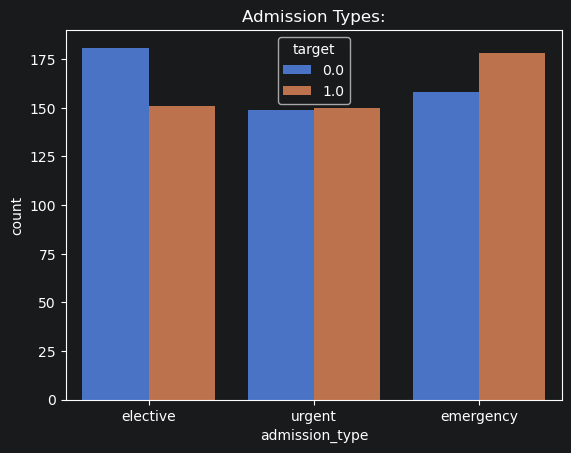

In [6]:
# Display admission types.
sns.countplot(data=df_medical, x="admission_type", hue="target", order=["elective", "urgent", "emergency"])
plt.title("Admission Types:")
plt.show()

### BMI Distribution
The BMI of a patient was expected to be a strong influence on whether a readmission would result from a hospital visit as well.

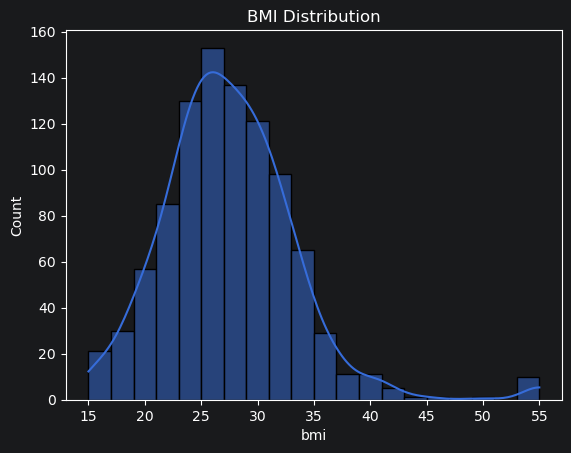

In [7]:
# Plot BMI histogram.
sns.histplot(df_medical["bmi"], bins=20, kde=True)
plt.title("BMI Distribution")
plt.show()

### Readmission by Chronic Conditions and Prior Admissions
Both the number of chronic conditions a patient had and their number of prior admissions should be strong indicators of whether a person will be readmitted to a hospital.

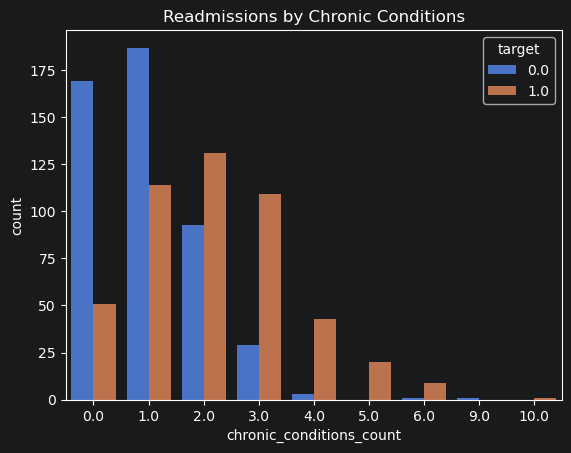

In [8]:
sns.countplot(data=df_medical, x='chronic_conditions_count', hue='target')
plt.title("Readmissions by Chronic Conditions")
plt.show()

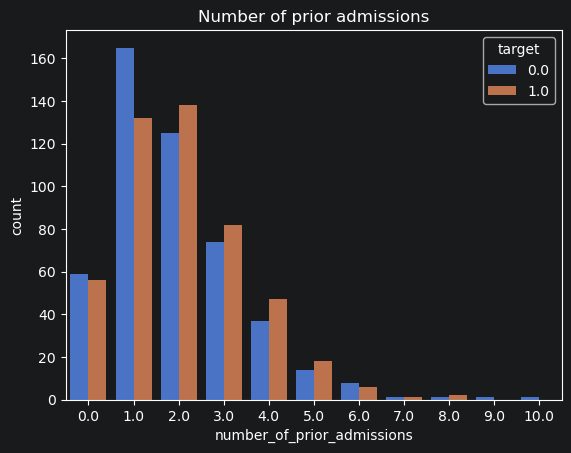

In [9]:
sns.countplot(data=df_medical, x='number_of_prior_admissions', hue='target')
plt.title("Number of prior admissions")
plt.show()

## Preprocessing

### Encode categories

In [10]:
# One-hot encoding on biological sex.
df_medical_enc = pd.get_dummies(df_medical, columns=["sex"])

# Manual encoding of admission type to preserve order of severity.
severity_order = {"elective":1, "urgent":5, "emergency":10}
df_medical_enc["admission_severity"] = df_medical_enc["admission_type"].map(severity_order)

df_medical_enc.head()

,age,bmi,number_of_prior_admissions,chronic_conditions_count,admission_type,severity_score,lab_result_severity,vitals_instability_score,treatment_complexity,hospital_load_index,physician_workload,target,sex_F,sex_M,admission_severity
0,35.0,31.4,0.0,1.0,urgent,66.0,52.8,46.8,38.5,0.61,NaN,1.0,False,True,5.0
1,22.0,23.6,4.0,3.0,urgent,78.9,77.9,37.1,66.1,0.06,0.37,1.0,True,False,5.0
2,43.0,22.2,1.0,1.0,emergency,22.6,71.3,52.8,14.9,0.41,0.81,0.0,True,False,10.0
3,23.0,26.3,1.0,1.0,emergency,28.8,54.2,71.4,22.9,0.92,0.40,1.0,True,False,10.0
4,24.0,27.0,2.0,NaN,NaN,80.5,60.1,16.7,60.5,0.48,0.48,1.0,False,True,NaN


#### Regarding manual encoding
The specific values for elective, urgent, and emergency were settled upon after some experimentation with values ranging between 1-10 for severity ranking. See the report for elaboration.

### Features and Target definition

In [11]:
# Drop unwanted features and target.
med_X = df_medical_enc.drop(["target", "admission_type"], axis=1, inplace=False)
# Define target.
med_y = df_medical_enc["target"]

### Train/test split

In [12]:
X_train, X_test, y_train, y_test = train_test_split(med_X, med_y, test_size=0.2, random_state=42)

### Pipeline setup

In [13]:
# Pipeline for preprocessing definition
preprocess_pipe = Pipeline(
    steps=[
        ("imputer", KNNImputer(n_neighbors=3, weights="distance")),
        ("scaler", StandardScaler()),
        ]
        )

### KNN Imputer
After some testing with SimpleImputer, IterativeImputer, and KNNImputer, KNNImputer gave the most improved results with the models below (save for the KNN model). In particular there was a small gain in recall and accuracy with it.

## Machine Learning Models

### Model 1: Logistic Regression

In [14]:
# Set up the pipeline.
reg_pipe = Pipeline(
    steps=[
        ("preprocessing", preprocess_pipe),
        ("model", LogisticRegression(max_iter=1000)),
    ]
)
# Train the pipeline.
reg_pipe.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 Pipeline(steps=[('imputer',
                                  KNNImputer(n_neighbors=3,
                                             weights='distance')),
                                 ('scaler', StandardScaler())])),
                ('model', LogisticRegression(max_iter=1000))])

#### Prediction and basic metrics of Logistic Regression

In [15]:
# Apply predictions
reg_y_predict = reg_pipe.predict(X_test)

# Accuracy readout
reg_accuracy = accuracy_score(y_test, reg_y_predict)
reg_precision = precision_score(y_test, reg_y_predict)
reg_recall = recall_score(y_test, reg_y_predict)
reg_f1_score = f1_score(y_test, reg_y_predict)

print(f"Accuracy: {reg_accuracy:.4f}")
print(f"Precision: {reg_precision:.4f}")
print(f"Recall: {reg_recall:.4f}")
print(f"F1 Score: {reg_f1_score:.4f}")

Accuracy: 0.8382
Precision: 0.8585
Recall: 0.8349
F1 Score: 0.8465


### Model 2: SVC

In [16]:
# Create and fit an SVC.
svc_pipe = Pipeline([
    ("preprocessing", preprocess_pipe),
    ("model", SVC(kernel="sigmoid", random_state=42)),
]
)
svc_pipe.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 Pipeline(steps=[('imputer',
                                  KNNImputer(n_neighbors=3,
                                             weights='distance')),
                                 ('scaler', StandardScaler())])),
                ('model', SVC(kernel='sigmoid', random_state=42))])

#### Prediction and basic metrics of SVC

In [17]:
# Apply predictions
svc_y_predict = svc_pipe.predict(X_test)

# Accuracy readout
svc_accuracy = accuracy_score(y_test, svc_y_predict)
svc_precision = precision_score(y_test, svc_y_predict)
svc_recall = recall_score(y_test, svc_y_predict)
svc_f1_score = f1_score(y_test, svc_y_predict)

print(f"Accuracy: {svc_accuracy:.4f}")
print(f"Precision: {svc_precision:.4f}")
print(f"Recall: {svc_recall:.4f}")
print(f"F1 Score: {svc_f1_score:.4f}")

Accuracy: 0.7745
Precision: 0.8119
Recall: 0.7523
F1 Score: 0.7810


### Model 3: Random Forest

In [18]:
# Set up and fit the pipeline.
forest_pipe = Pipeline([
    ("preprocessing", preprocess_pipe),
    ("model", RandomForestClassifier(n_estimators=101, random_state=42))
])

forest_pipe.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 Pipeline(steps=[('imputer',
                                  KNNImputer(n_neighbors=3,
                                             weights='distance')),
                                 ('scaler', StandardScaler())])),
                ('model',
                 RandomForestClassifier(n_estimators=101, random_state=42))])

#### Prediction and basic metrics of Forest

In [19]:
# Apply predictions
forest_y_predict = forest_pipe.predict(X_test)

# Accuracy readout
forest_accuracy = accuracy_score(y_test, forest_y_predict)
forest_precision = precision_score(y_test, forest_y_predict)
forest_recall = recall_score(y_test, forest_y_predict)
forest_f1_score = f1_score(y_test, forest_y_predict)

print(f"Accuracy: {forest_accuracy:.4f}")
print(f"Precision: {forest_precision:.4f}")
print(f"Recall: {forest_recall:.4f}")
print(f"F1 Score: {forest_f1_score:.4f}")

Accuracy: 0.8186
Precision: 0.8673
Recall: 0.7798
F1 Score: 0.8213


### Model 4: KNN

In [20]:
# Define a pipeline for KNN.
knn_pipe = Pipeline(
    [("imputer", SimpleImputer(strategy="median")),
     ("scaler", StandardScaler()),
     ("model", KNeighborsClassifier(n_neighbors=5))
     ]
)

# Fit the knn pipeline.
knn_pipe.fit(X_train, y_train)

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()),
                ('model', KNeighborsClassifier())])

#### Prediction and basic metrics of KNN

In [21]:
# Apply predictions
knn_y_predict = knn_pipe.predict(X_test)

# Accuracy readout
knn_accuracy = accuracy_score(y_test, knn_y_predict)
knn_precision = precision_score(y_test, knn_y_predict)
knn_recall = recall_score(y_test, knn_y_predict)
knn_f1_score = f1_score(y_test, knn_y_predict)

print(f"Accuracy: {knn_accuracy:.4f}")
print(f"Precision: {knn_precision:.4f}")
print(f"Recall: {knn_recall:.4f}")
print(f"F1 Score: {knn_f1_score:.4f}")

Accuracy: 0.7696
Precision: 0.7925
Recall: 0.7706
F1 Score: 0.7814


### Cross validation of Logistic Regression

In [22]:
reg_scores = cross_val_score(reg_pipe, X_train, y_train, cv=5)
reg_cv_mean = reg_scores.mean()

print(f"Mean score: {reg_cv_mean:.4f}")

Mean score: 0.8076


### Grid Search of Logistic Regression

In [23]:
### Hyperparameters to test
reg_param_grid = {
    "model__max_iter": [25, 50, 100, 250, 500],
    "model__C": [0.1, 0.5, 1.0, 10.0]
}

# Create and fit the grid search object.
reg_grid_search = GridSearchCV(reg_pipe, param_grid=reg_param_grid, cv=5)
reg_grid_search.fit(X_train, y_train)

# Print the results.
print(f"Best parameters: {reg_grid_search.best_params_}")
print(f"Best score: {reg_grid_search.best_score_}")

Best parameters: {'model__C': 0.1, 'model__max_iter': 25}
Best score: 0.8137438276223253


### Cross-validation of SVC

In [24]:
svc_scores = cross_val_score(svc_pipe, X_train, y_train, cv=5)
svc_cv_mean = svc_scores.mean()

print(f"Cross Validation Mean Score: {svc_cv_mean:.4f}")

Cross Validation Mean Score: 0.7941


### Grid Search of SVC

In [25]:
### Hyperparameters to test
svc_param_grid = {
    "model__kernel": ["linear", "poly", "rbf", "sigmoid"],
    "model__C": [0.1, 0.5, 1.0, 10.0]
}

# Create and fit the grid search object.
svc_grid_search = GridSearchCV(svc_pipe, param_grid=svc_param_grid, cv=5)
svc_grid_search.fit(X_train, y_train)

# Print the results.
print(f"Best parameters: {svc_grid_search.best_params_}")
print(f"Best score: {svc_grid_search.best_score_}")

Best parameters: {'model__C': 0.1, 'model__kernel': 'rbf'}
Best score: 0.811289839892264


### Cross-validation of Random Forest

In [26]:
forest_scores = cross_val_score(forest_pipe, X_train, y_train, cv=5)
forest_cv_mean = forest_scores.mean()

print(f"Mean score: {reg_cv_mean:.4f}")

Mean score: 0.8076


### Grid Search of Random Forest

In [27]:
### Hyperparameters to test
forest_param_grid = {
    "model__n_estimators": [50, 100, 150],
    "model__criterion": ["gini", "entropy", "log_loss"]
}

# Create and fit the grid search object.
forest_grid_search = GridSearchCV(forest_pipe, param_grid=forest_param_grid, cv=5)
forest_grid_search.fit(X_train, y_train)

# Print the results.
print(f"Best parameters: {forest_grid_search.best_params_}")
print(f"Best score: {forest_grid_search.best_score_}")

Best parameters: {'model__criterion': 'gini', 'model__n_estimators': 150}
Best score: 0.8051698339069281


## Evaluate Models

### Logistic Regression

#### Confusion Matrix

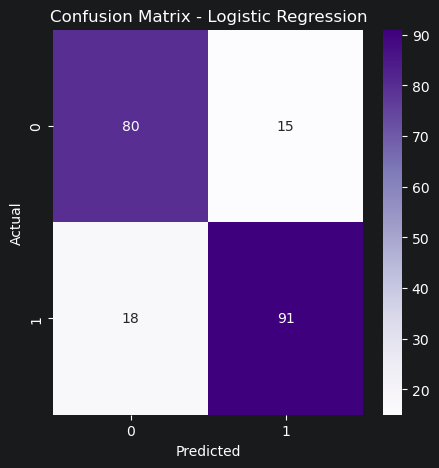


Classification Report: 
              precision    recall  f1-score   support

         0.0       0.82      0.84      0.83        95
         1.0       0.86      0.83      0.85       109

    accuracy                           0.84       204
   macro avg       0.84      0.84      0.84       204
weighted avg       0.84      0.84      0.84       204



In [28]:
# Create a confusion matrix for LogReg.
reg_confusion = confusion_matrix(y_test, reg_y_predict)

plt.figure(figsize=[5, 5])
sns.heatmap(reg_confusion, annot=True, fmt="d", cmap="Purples")
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Print the classification report for logistic regression.
print(f"\nClassification Report: \n{classification_report(y_test, reg_y_predict)}")


#### Logistic Regression comments
The logistic regression model, even though it was the base model used, ended up testing the best. Its accuracy was the greatest, and in terms of precision and recall it also performed the best. False negatives matter most in medical applications, so logistic regression performing the best places it far ahead of the other options. Still, scores near 0.85 are overall not very likely to be suitable for deployment.


### SVC Model

#### Confusion Matrix

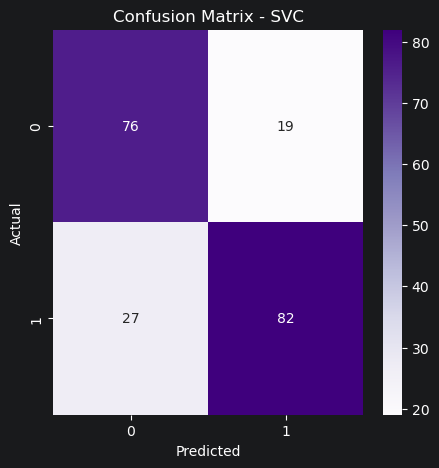


Classification Report: 
              precision    recall  f1-score   support

         0.0       0.74      0.80      0.77        95
         1.0       0.81      0.75      0.78       109

    accuracy                           0.77       204
   macro avg       0.77      0.78      0.77       204
weighted avg       0.78      0.77      0.77       204



In [29]:
# Create a confusion matrix.
svc_confusion = confusion_matrix(y_test, svc_y_predict)

plt.figure(figsize=[5, 5])
sns.heatmap(svc_confusion, annot=True, fmt="d", cmap="Purples")
plt.title("Confusion Matrix - SVC")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Print the classification report for SVC.
print(f"\nClassification Report: \n{classification_report(y_test, svc_y_predict)}")

In [30]:
reg_coef = reg_pipe.named_steps["model"].coef_
print(reg_coef)

[[-0.04802982  0.04115316  0.1444848   0.64373746  1.6077885   0.7577105
   1.39171231  0.27614999 -0.06151149 -0.08862039  0.09457971  0.1340427
   0.24295883]]


#### SVC comments
The SVM model performed much more poorly than expected, overall similar to the KNN model. The especially poor performance with respect to false negatives was disappointing. Changing the parameters of the model to match the grid search performed after could improve its score, but even so the outlook for the model's suitability for prediction is not good.

### Random Forest

#### Confusion Matrix

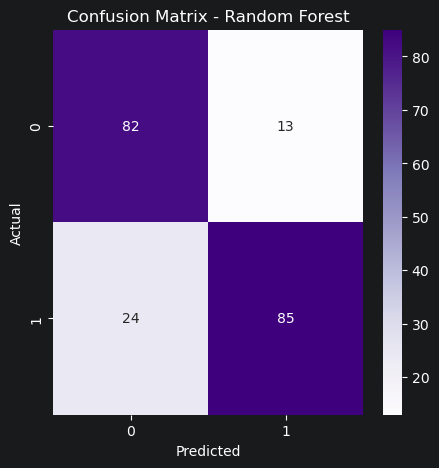


Classification Report: 
              precision    recall  f1-score   support

         0.0       0.77      0.86      0.82        95
         1.0       0.87      0.78      0.82       109

    accuracy                           0.82       204
   macro avg       0.82      0.82      0.82       204
weighted avg       0.82      0.82      0.82       204



In [31]:
# Create a confusion matrix.
forest_confusion = confusion_matrix(y_test, forest_y_predict)

plt.figure(figsize=[5, 5])
sns.heatmap(forest_confusion, annot=True, fmt="d", cmap="Purples")
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Feature importances.


# Print the classification report for random forest.
print(f"\nClassification Report: \n{classification_report(y_test, forest_y_predict)}")

#### Random Forest comments
The random forest model performed second-best overall. Its overall good score (relative to other models) from grid search and cross-validation make its outlook for suitability more optimistic than the SVC or KNN, but that should be tempered by the high rate of false negatives. Further hyperparameter tuning and more extensive feature engineering might be able to reduce the gap between the random forest and logistic regression.

### KNN

#### Confusion Matrix

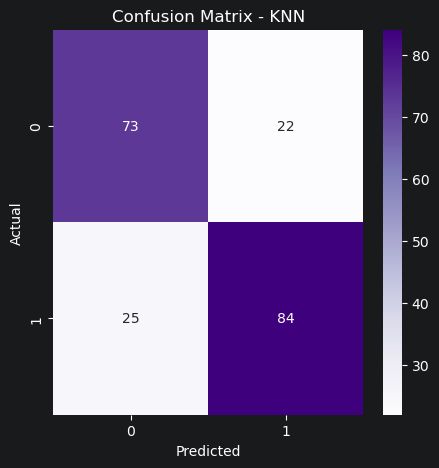


Classification Report: 
              precision    recall  f1-score   support

         0.0       0.74      0.77      0.76        95
         1.0       0.79      0.77      0.78       109

    accuracy                           0.77       204
   macro avg       0.77      0.77      0.77       204
weighted avg       0.77      0.77      0.77       204



In [32]:
# Create a confusion matrix.
knn_confusion = confusion_matrix(y_test, knn_y_predict)

plt.figure(figsize=[5, 5])
sns.heatmap(knn_confusion, annot=True, fmt="d", cmap="Purples")
plt.title("Confusion Matrix - KNN")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Print the classification report for logistic regression.
print(f"\nClassification Report: \n{classification_report(y_test, knn_y_predict)}")

#### KNN comments
The KNN model was explored as an option because of the positive effect of using the KNNImputer on the other models. However, it performed overall the most poorly. Swapping to other imputers (Simple, Iterative) helped the KNN model but hurt the performance of every other model. With specific tailoring the KNN model might be improved, but its base performance suggests that strategy is not the correct one.

## Final Results

In [33]:
accuracy = reg_accuracy
cv_mean = reg_cv_mean
best_score = reg_grid_search.best_score_

## Summarize Findings

Every model performed roughly similarly, ranging between scores in each category of .75-.85. Within these bounds SVC and KNN performed the poorest, Random Forest better, and Logistic Regression the best. While the precision and accuracy of the Random Forest were close to the performance of the Logistic Regression model, its recall was significantly worse. This hurt both it in its F1 score and its overall suitability for application to the medical field.

Even though Logistic Regression performed the best, its metrics still cannot be considered good enough for deployment. Fine tuning of the approach to the data with better feature engineering would likely improve all model's performance, but more development would be needed in order to consider even the best of them close to ready for actual use.

## FINAL GRADER OUTPUT (*GRADER CONTRACT*)

In [34]:
RESULTS = {
    "accuracy": float(accuracy),  # logistic regression accuracy
    "cv_mean": float(cv_mean),  # cv_mean of logistic regression
    "best_score": float(best_score)  # logistic regression grid search best score
}

print("ML Classification Project Completed")
print("-" * 45)
for key, value in RESULTS.items():
    print(f"{key}: {value:.4f}" if isinstance(value, float) else f"{key}: {value}")


ML Classification Project Completed
---------------------------------------------
accuracy: 0.8382
cv_mean: 0.8076
best_score: 0.8137


In [35]:
# This is a contract for the grading script.
# Failure to hardcode metrics or change metric names will result in incorrect scoring.

GRADER = {
    "task": "classification",
    "metrics": {
        "accuracy": 0.8382,
        "cv_mean": 0.8076,
        "best_score": 0.8137
    }
}
